# Support Vector Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

In [2]:
# Generate noisy sine data
np.random.seed(42)
X = np.sort(5 * np.random.rand(50, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 50)

In [3]:
# Scale (important for SVR!)
sc_X = StandardScaler(); sc_y = StandardScaler()
X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y.reshape(-1, 1)).ravel()

In [4]:
# Train SVR with RBF kernel
svr = SVR(kernel='rbf', C=1.0, epsilon=0.2, gamma='scale')
svr.fit(X_scaled, y_scaled)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.2
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [5]:
# Predict on a fine grid
X_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_grid_scaled = sc_X.transform(X_grid)
y_pred = sc_y.inverse_transform(svr.predict(X_grid_scaled).reshape(-1, 1))

In [6]:
# Identify support vectors
sv_idx = svr.support_
sv_X = sc_X.inverse_transform(X_scaled[sv_idx])
sv_y = sc_y.inverse_transform(y_scaled[sv_idx].reshape(-1, 1))

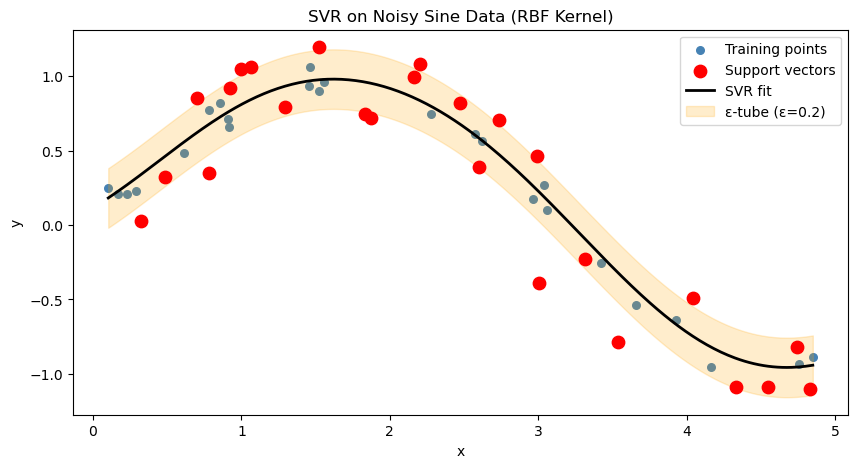

In [7]:
# Plot
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='steelblue', s=30, label='Training points')
plt.scatter(sv_X, sv_y, color='red', s=80, zorder=5, label='Support vectors')
plt.plot(X_grid, y_pred, color='black', lw=2, label='SVR fit')
plt.fill_between(X_grid.ravel(),
                 (y_pred - 0.2).ravel(),
                 (y_pred + 0.2).ravel(),
                 alpha=0.2, color='orange', label='ε-tube (ε=0.2)')
plt.legend(); plt.xlabel('x'); plt.ylabel('y')
plt.title('SVR on Noisy Sine Data (RBF Kernel)')
plt.show()